# 06 - Model Evaluation

## Objective

This notebook reloads the saved Random Forest and XGBoost pipelines, recreates the same temporal test set and compares overall and product-level errors.

**Input:** modeling data, saved pipelines and training results  
**Outputs:** four evaluation reports in `reports/`  
**Next notebook:** `07_stock_recommendation_engine.ipynb`

## Imports and Load Data and Models

In [1]:
import os
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
os.chdir(ROOT)

import sys
import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(str(ROOT))
from src.evaluation import evaluate_forecast, error_by_product
from src.importance import get_feature_importance

DATA_PATH = ROOT / "data" / "processed" / "modeling_dataset.csv"
MODELS_PATH = ROOT / "artifacts" / "models"

df = pd.read_csv(DATA_PATH, parse_dates=["sale_date"])
rf_model = joblib.load(MODELS_PATH / "random_forest_model.pkl")
xgb_model = joblib.load(MODELS_PATH / "xgboost_model.pkl")
print("Shape:", df.shape)

Shape: (6000, 15)


## Recreate the Same Temporal Test Set

In [2]:
target = "quantity_sold"
numeric_features = [
    "unit_price_1d", "day_of_week", "day_of_month", "month",
    "week_of_year", "is_weekend", "quantity_1d", "quantity_7d",
    "quantity_14d", "rolling_1d", "rolling_7d", "rolling_14d",
]
categorical_features = ["product_name"]
feature_columns = numeric_features + categorical_features

unique_dates = df["sale_date"].sort_values().unique()
split_index = int(len(unique_dates) * 0.8)
train_dates = unique_dates[:split_index]
test_dates = unique_dates[split_index:]
test = df[df["sale_date"].isin(test_dates)].copy()

X_test = test[feature_columns]
y_test = test[target].to_numpy()
assert max(train_dates) < min(test_dates)
print("Test period:", test["sale_date"].min(), "to", test["sale_date"].max())

Test period: 2026-02-19 00:00:00 to 2026-05-29 00:00:00


## Generate Predictions and Overall Metrics

In [3]:
y_pred_rf = np.clip(rf_model.predict(X_test), 0, None)
y_pred_xgb = np.clip(xgb_model.predict(X_test), 0, None)

rf_results = evaluate_forecast(y_test, y_pred_rf)
xgb_results = evaluate_forecast(y_test, y_pred_xgb)
metrics_df = pd.DataFrame([
    {"model_name": "Random Forest", **rf_results},
    {"model_name": "XGBoost", **xgb_results},
])
metrics_df.round(2)

,model_name,MAE,RMSE,MAPE,WAPE
0,Random Forest,1.32,1.85,63.50,81.85
1,XGBoost,1.30,1.87,62.58,80.29


## Confirm Results Match Model Training

In [4]:
training_results = pd.read_csv(ROOT / "reports" / "model_training_results.csv")
training_results = training_results.rename(columns={"Model": "model_name"})
metric_columns = ["MAE", "RMSE", "MAPE", "WAPE"]
reproduction_check = training_results.merge(metrics_df, on="model_name", suffixes=("_training", "_evaluation"))
for metric in metric_columns:
    reproduction_check[f"{metric}_difference"] = reproduction_check[f"{metric}_evaluation"] - reproduction_check[f"{metric}_training"]
    assert np.allclose(
        reproduction_check[f"{metric}_training"],
        reproduction_check[f"{metric}_evaluation"],
        equal_nan=True,
    )
reproduction_check.round(6)

,model_name,MAE_training,RMSE_training,MAPE_training,WAPE_training,MAE_evaluation,RMSE_evaluation,MAPE_evaluation,WAPE_evaluation,MAE_difference,RMSE_difference,MAPE_difference,WAPE_difference
0,Random Forest,1.321885,1.849646,63.501327,81.850435,1.321885,1.849646,63.501327,81.850435,0.0,0.0,-0.0,0.0
1,XGBoost,1.296611,1.869340,62.575466,80.285498,1.296611,1.869340,62.575466,80.285498,0.0,-0.0,0.0,0.0


## Build Prediction Comparison

Signed error is defined as `prediction - actual`. Positive values mean overprediction and negative values mean underprediction. Absolute error ignores direction and is used for MAE.

In [5]:
eval_df = test[["sale_date", "product_name", "quantity_sold"]].reset_index(drop=True).copy()
eval_df["rf_prediction"] = y_pred_rf
eval_df["xgb_prediction"] = y_pred_xgb
eval_df["rf_signed_error"] = eval_df["rf_prediction"] - eval_df["quantity_sold"]
eval_df["xgb_signed_error"] = eval_df["xgb_prediction"] - eval_df["quantity_sold"]
eval_df["rf_abs_error"] = eval_df["rf_signed_error"].abs()
eval_df["xgb_abs_error"] = eval_df["xgb_signed_error"].abs()
eval_df.head()

,sale_date,product_name,quantity_sold,rf_prediction,xgb_prediction,rf_signed_error,xgb_signed_error,rf_abs_error,xgb_abs_error
0,2026-02-19,Bag Delivery 45L,3,2.393580,2.959170,-0.606420,-0.040830,0.606420,0.040830
1,2026-02-19,Bag Delivery 80L,5,1.103039,1.591204,-3.896961,-3.408796,3.896961,3.408796
2,2026-02-19,Balaclava,0,0.977849,1.002201,0.977849,1.002201,0.977849,1.002201
3,2026-02-19,Baú Moto 30L,2,0.715345,0.783431,-1.284655,-1.216569,1.284655,1.216569
4,2026-02-19,Capa de Chuva,0,1.923837,2.009619,1.923837,2.009619,1.923837,2.009619


## Evaluate Error by Product

In [6]:
product_results = []
for product_name, product_df in eval_df.groupby("product_name"):
    product_results.append(error_by_product(product_df, "rf_prediction", "Random Forest"))
    product_results.append(error_by_product(product_df, "xgb_prediction", "XGBoost"))

product_error_df = pd.DataFrame(product_results)
xgb_product_errors = product_error_df[product_error_df["model_name"] == "XGBoost"]

print("Best XGBoost products by RMSE:")
display(xgb_product_errors.nsmallest(5, "RMSE").round(2))
print("Worst XGBoost products by RMSE:")
display(xgb_product_errors.nlargest(5, "RMSE").round(2))
print("Largest XGBoost underpredictions:")
display(xgb_product_errors[xgb_product_errors["signed_total_error"] < 0].nsmallest(5, "signed_total_error").round(2))
print("Largest XGBoost overpredictions:")
display(xgb_product_errors[xgb_product_errors["signed_total_error"] > 0].nlargest(5, "signed_total_error").round(2))

Best XGBoost products by RMSE:


,product_name,model_name,MAE,RMSE,MAPE,WAPE,total_actual_quantity,total_predicted_quantity,signed_total_error,error_direction
17,Intercomunicador,XGBoost,0.25,0.55,83.82,195.16,13,15.41,2.41,Overprediction
11,Capacete LS2,XGBoost,0.44,0.70,84.77,150.58,29,22.00,-7.00,Underprediction
21,Retrovisor Esportivo,XGBoost,0.74,0.99,56.96,127.34,58,54.38,-3.62,Underprediction
5,Balaclava,XGBoost,0.93,1.23,40.62,103.29,90,86.16,-3.84,Underprediction
15,Carregador USB Moto,XGBoost,1.04,1.50,58.46,114.56,91,66.41,-24.59,Underprediction


Worst XGBoost products by RMSE:


,product_name,model_name,MAE,RMSE,MAPE,WAPE,total_actual_quantity,total_predicted_quantity,signed_total_error,error_direction
1,Bag Delivery 45L,XGBoost,2.58,3.36,84.08,64.16,402,338.21,-63.79,Underprediction
23,Suporte Celular Moto,XGBoost,1.87,2.44,74.96,59.80,312,310.32,-1.68,Underprediction
9,Capa de Chuva,XGBoost,2.01,2.42,72.74,83.49,241,231.27,-9.73,Underprediction
13,Capacete Pro Tork,XGBoost,1.54,2.01,48.09,81.57,189,155.93,-33.07,Underprediction
19,Luva Motoboy,XGBoost,1.52,1.87,58.24,65.91,231,242.65,11.65,Overprediction


Largest XGBoost underpredictions:


,product_name,model_name,MAE,RMSE,MAPE,WAPE,total_actual_quantity,total_predicted_quantity,signed_total_error,error_direction
1,Bag Delivery 45L,XGBoost,2.58,3.36,84.08,64.16,402,338.21,-63.79,Underprediction
13,Capacete Pro Tork,XGBoost,1.54,2.01,48.09,81.57,189,155.93,-33.07,Underprediction
15,Carregador USB Moto,XGBoost,1.04,1.50,58.46,114.56,91,66.41,-24.59,Underprediction
7,Baú Moto 30L,XGBoost,1.14,1.51,45.02,87.67,130,105.58,-24.42,Underprediction
3,Bag Delivery 80L,XGBoost,1.50,1.86,51.83,98.53,152,132.23,-19.77,Underprediction


Largest XGBoost overpredictions:


,product_name,model_name,MAE,RMSE,MAPE,WAPE,total_actual_quantity,total_predicted_quantity,signed_total_error,error_direction
19,Luva Motoboy,XGBoost,1.52,1.87,58.24,65.91,231,242.65,11.65,Overprediction
17,Intercomunicador,XGBoost,0.25,0.55,83.82,195.16,13,15.41,2.41,Overprediction


## Error Distribution

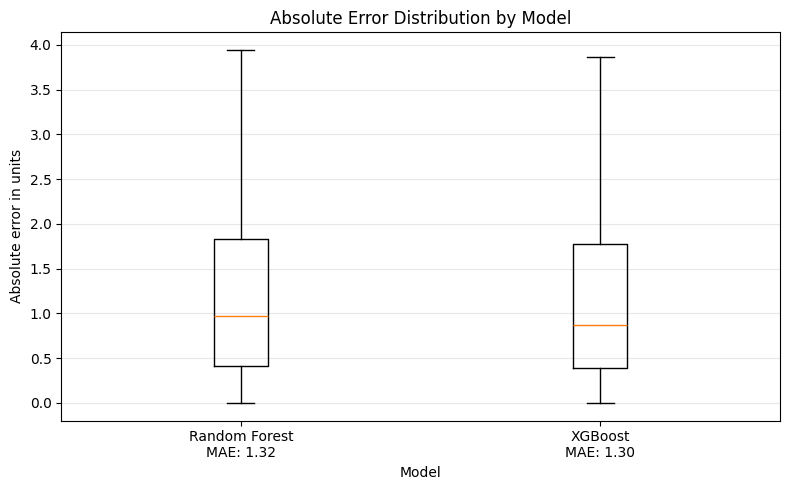

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [eval_df["rf_abs_error"], eval_df["xgb_abs_error"]],
    tick_labels=[f"Random Forest\nMAE: {rf_results['MAE']:.2f}", f"XGBoost\nMAE: {xgb_results['MAE']:.2f}"],
    showfliers=False,
)
ax.set_title("Absolute Error Distribution by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Absolute error in units")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Visual Comparison for Selected Products

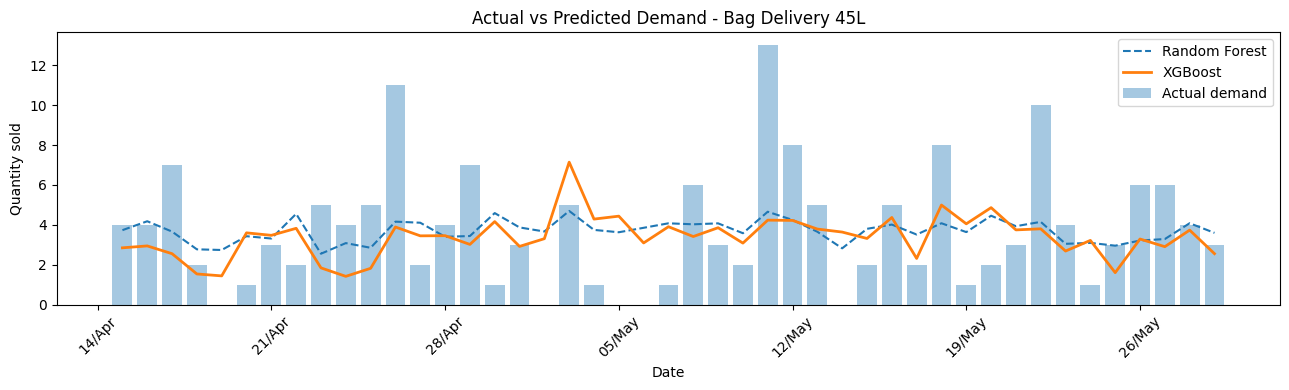

In [8]:
product_summary = (
    eval_df.groupby("product_name", as_index=False)
    .agg(total_actual_quantity=("quantity_sold", "sum"), xgb_mae=("xgb_abs_error", "mean"))
)
selected_products = [
    product_summary.nlargest(1, "total_actual_quantity").iloc[0]["product_name"],
    product_summary.nlargest(1, "xgb_mae").iloc[0]["product_name"],
]

for product_name in dict.fromkeys(selected_products):
    plot_df = eval_df[eval_df["product_name"] == product_name].sort_values("sale_date").tail(45)
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.bar(plot_df["sale_date"], plot_df["quantity_sold"], alpha=0.4, label="Actual demand")
    ax.plot(plot_df["sale_date"], plot_df["rf_prediction"], "--", label="Random Forest")
    ax.plot(plot_df["sale_date"], plot_df["xgb_prediction"], linewidth=2, label="XGBoost")
    ax.set_title(f"Actual vs Predicted Demand - {product_name}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Quantity sold")
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

## Feature Importance

In [9]:
rf_importance = get_feature_importance(rf_model).rename(columns={"importance": "importance_rf"})
xgb_importance = get_feature_importance(xgb_model).rename(columns={"importance": "importance_xgb"})
importance_df = rf_importance.merge(xgb_importance, on="feature", how="outer").fillna(0)
importance_df = importance_df.sort_values("importance_xgb", ascending=False).reset_index(drop=True)
importance_df.head(10)

,feature,importance_rf,importance_xgb
0,rolling_14d,0.328576,0.157461
1,product_name_Bag Delivery 45L,0.009635,0.083745
2,product_name_Suporte Celular Moto,0.002338,0.054184
3,product_name_Capa de Chuva,0.007408,0.054011
4,rolling_7d,0.073467,0.048121
5,week_of_year,0.080171,0.044779
6,is_weekend,0.006222,0.043182
7,product_name_Capacete LS2,0.000059,0.043175
8,unit_price_1d,0.149991,0.042832
9,month,0.026749,0.038963


## Select Final Model and Save Reports

In [10]:
selected_model = metrics_df.sort_values(["MAE", "RMSE"]).iloc[0]["model_name"]
mae_difference = abs(rf_results["MAE"] - xgb_results["MAE"])
print("Selected model:", selected_model)
print("Absolute MAE difference between models:", round(mae_difference, 4))
assert selected_model == "XGBoost", "The final-model choice must be reviewed if XGBoost no longer has the lowest MAE."

REPORTS_PATH = ROOT / "reports"
REPORTS_PATH.mkdir(parents=True, exist_ok=True)
eval_df.to_csv(REPORTS_PATH / "predictions_comparison.csv", index=False, encoding="utf-8")
metrics_df.to_csv(REPORTS_PATH / "model_evaluation_summary.csv", index=False, encoding="utf-8")
product_error_df.to_csv(REPORTS_PATH / "model_evaluation_by_product.csv", index=False, encoding="utf-8")
importance_df.to_csv(REPORTS_PATH / "feature_importance_final.csv", index=False, encoding="utf-8")

print("Saved four evaluation reports to:", REPORTS_PATH.resolve())

Selected model: XGBoost
Absolute MAE difference between models: 0.0253
Saved four evaluation reports to: C:\DEV\motostock-ai\reports


## Conclusion

The saved pipelines reproduce the training-notebook results on the same test dates. XGBoost is selected because it has the lower MAE, MAPE and WAPE. Random Forest has a slightly lower RMSE, so the models are very close and XGBoost should not be presented as better in every metric.

The product tables separate error size from error direction. This matters for stock planning because underprediction can increase stockout risk, while overprediction can increase excess stock.

The next notebook uses the selected XGBoost pipeline to create a simple 14-day stock recommendation report.